# Notebook 18 — Supplementary figures

Renders supplementary figures S1–S6 as vector PDFs to `output/figures/supp/`. Paired with [`17_main_figures.ipynb`](17_main_figures.ipynb).

## Setup


In [1]:
"""NB18 — supplementary figures S1-S6."""
from __future__ import annotations
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sns

from gtex_biomarkers.config import Config

Config.ensure_dirs()
TBL = Config.TABLES_DIR
FIG_DIR = Config.FIGURES_DIR / "supp"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 10.5,
    "axes.titlesize": 12.0,
    "axes.titleweight": "bold",
    "axes.labelsize": 10.5,
    "axes.labelweight": "bold",
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9.0,
    "savefig.dpi": 220,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

## Data loads


In [2]:
print("Loading canonical CSVs...")
pc_auc        = pd.read_csv(TBL / "pc_auc_results.csv")
pair_class    = pd.read_csv(TBL / "pair_class_balance.csv")
rf_all        = pd.read_csv(TBL / "cv_results_all_tissue_rf.csv")
lr_all        = pd.read_csv(TBL / "cv_results_all_tissue_pathology.csv")
threeway      = pd.read_csv(TBL / "cv_three_way_comparison.csv")
conf_imp      = pd.read_csv(TBL / "confounder_feature_importances.csv")
cmp_lr_rf     = pd.read_csv(TBL / "comparison_lr_vs_rf.csv")
six_model     = pd.read_csv(TBL / "liver_cirrhosis_six_model_auc.csv")
pca_cumvar    = pd.read_csv(TBL / "pca_cumulative_variance_wb20k.csv")
pca_scores    = pd.read_csv(TBL / "pca_donor_scores_wb20k.csv")
liver_pc_uv   = pd.read_csv(TBL / "liver_cirrhosis_pc_univariate_auc.csv")
liver_pc_gini = pd.read_csv(TBL / "liver_cirrhosis_pc_rf_gini.csv")
validation    = pd.read_csv(TBL / "validation_pc_vs_rf.csv")
spikein       = pd.read_csv(TBL / "spikein_validation.csv")
gene_imp      = pd.read_csv(TBL / "pc_gene_importance_full.csv")
gsea          = pd.read_csv(TBL / "gsea_pathway_enrichment.csv")
plasma_full   = pd.read_csv(TBL / "cross_organ_plasma_gsea_full.csv")
plasma_spec   = pd.read_csv(TBL / "cross_organ_specificity_plasma.csv")
plasma_own    = pd.read_csv(TBL / "organ_enrichment_plasma_gsea.csv")
leading_edge  = pd.read_csv(TBL / "organ_leading_edge_ranks.csv")
mr_steat_up   = pd.read_csv(TBL / "mr_steatosis_up100_same_direction.csv")
mr_cirr_up    = pd.read_csv(TBL / "mr_cirrhosis_up100_same_direction.csv")
mr_steat_dn   = pd.read_csv(TBL / "mr_steat_down_opposite_direction.csv")
mr_cirr_dn    = pd.read_csv(TBL / "mr_cirr_down_opposite_direction.csv")
lt_cirr_full  = pd.read_csv(TBL / "liver_tissue_fc_cirrhosis_olink.csv")
lt_steat_full = pd.read_csv(TBL / "liver_tissue_fc_steatosis_olink.csv")
blood_steat_up   = pd.read_csv(TBL / "blood_fc_steatosis_top100_up.csv")
blood_cirr_up    = pd.read_csv(TBL / "blood_fc_cirrhosis_top100_up.csv")

# Qualifying pairs (dynamic)
mask_q = (pc_auc["auc_pc_conf"] >= 0.60) & (pc_auc["delta_pc"] >= Config.DELTA_THRESH)
QUAL = pc_auc[mask_q].sort_values("delta_pc", ascending=False).reset_index(drop=True)
QUAL_LABELS = [f"{r.tissue.replace('Small Intestine - Terminal Ileum','Small Intestine')} - {r.category}"
               for r in QUAL.itertuples()]
QUAL_PAIRS = list(zip(QUAL["tissue"], QUAL["category"]))
print(f"Qualifying pairs ({len(QUAL)}): {QUAL_LABELS}")

CB = "#4878A8"   # blue
WARM = "#C44E52" # red
NEU = "#9DB4C0"  # grey
GREEN = "#2ecc71"
ORANGE = "#E08E2A"

QUAL_COLORS = {lbl: c for lbl, c in zip(QUAL_LABELS, [WARM, ORANGE, CB, "#7E57C2"])}


Loading canonical CSVs...
Qualifying pairs (4): ['Liver - cirrhosis', 'Liver - steatosis', 'Small Intestine - nodularity', 'Lung - congestion']


## Helpers


In [3]:
def in_qual(tissue: str, category: str) -> bool:
    return any((tissue == t) and (category == c) for t, c in QUAL_PAIRS)


def save_fig(fig, label: str) -> None:
    """Save fig as figure_<label>.pdf under FIG_DIR and show inline."""
    pdf_path = FIG_DIR / f"figure_{label}.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"  wrote {pdf_path.name}")
    plt.show()

## Figure S1 — Cohort and clinical co-variate structure

Cohort assembly + PCA variance decomposition for the 803-donor whole-blood set.

Building Figure S1 (cohort + PCA variance)...


Qualifying pairs: 4
  - Liver - cirrhosis
  - Liver - steatosis
  - Small Intestine - Terminal Ileum - nodularity
  - Lung - congestion


  wrote figure_S1.pdf


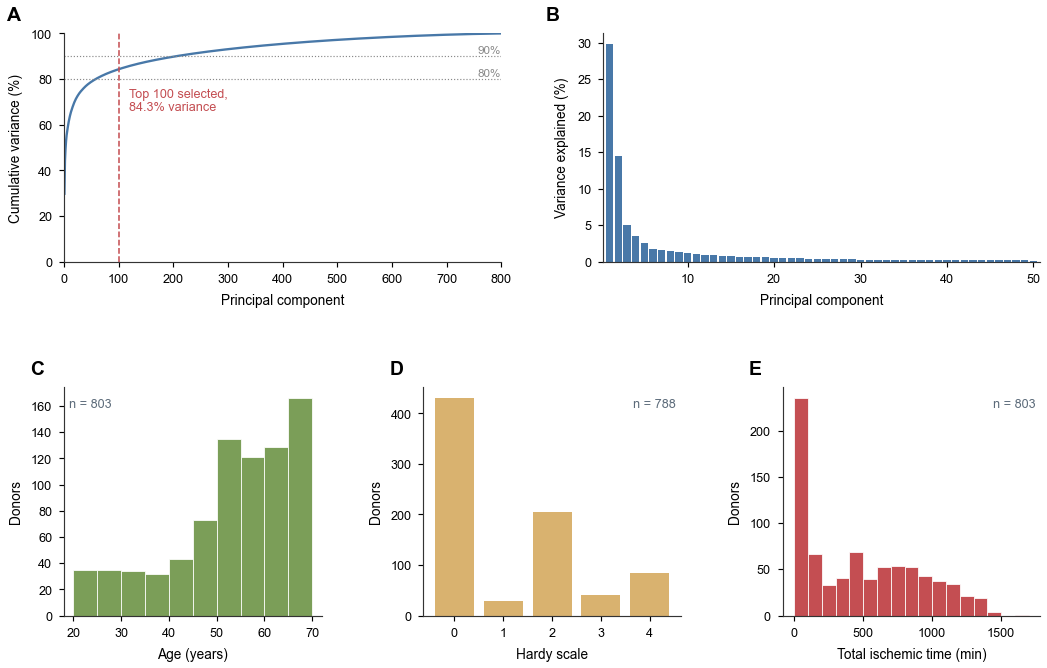

In [4]:
print("Building Figure S1 (cohort + PCA variance)...")
from gtex_biomarkers.supp_figures import build_S1

fig = build_S1()
save_fig(fig, "S1")

## Figure S2 — Screening pipeline: covariate-orthogonal filter and full 59-pair landscape


Building Figure S2 (screening pipeline: covariate filter + full landscape)...


  wrote figure_S2.pdf


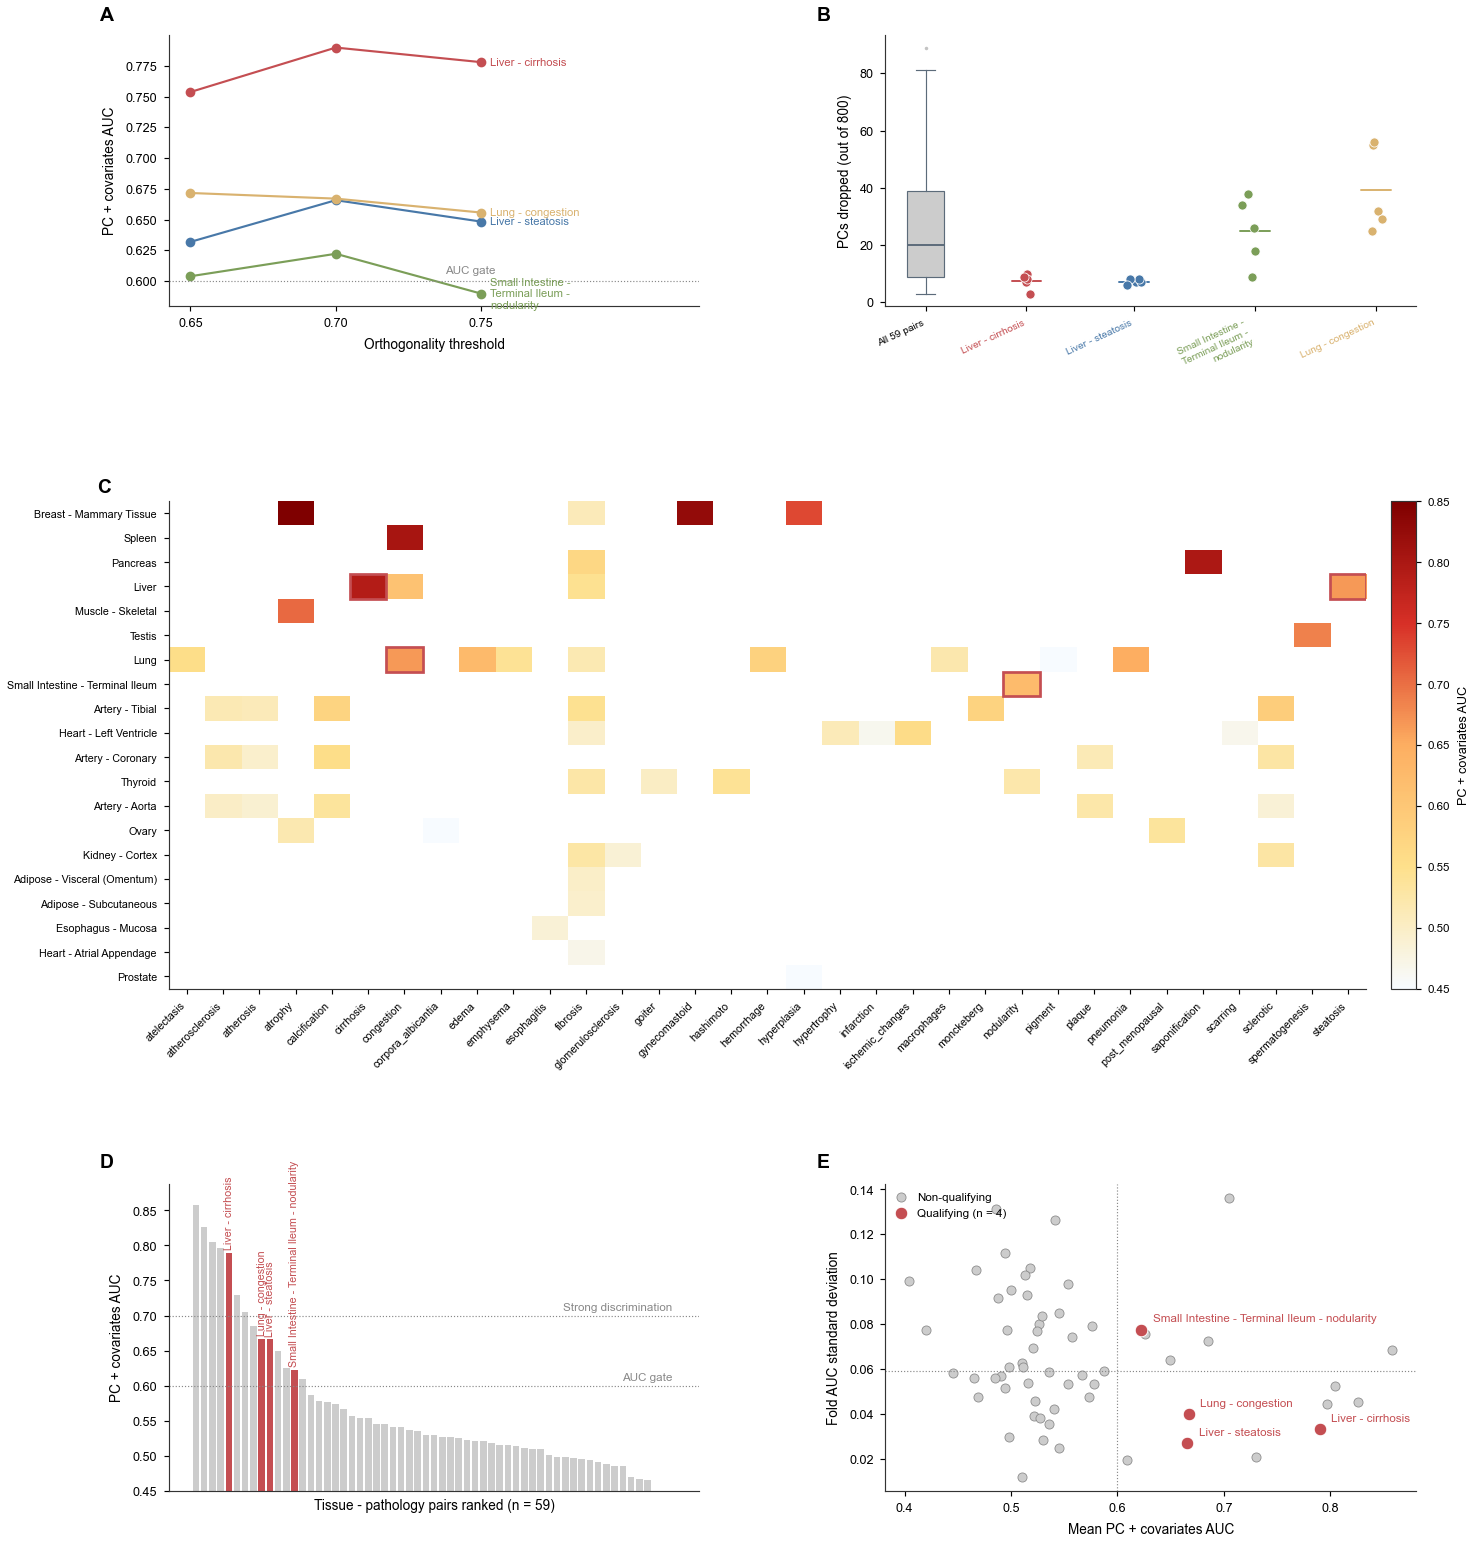

In [5]:
print("Building Figure S2 (screening pipeline: covariate filter + full landscape)...")
from gtex_biomarkers.supp_figures import build_S2

fig = build_S2()
save_fig(fig, "S2")

## Figure S3 — Three-way model comparison and PC selection


Building Figure S3 (three-way model comparison + LR vs RF + six-model)...


  wrote figure_S3.pdf


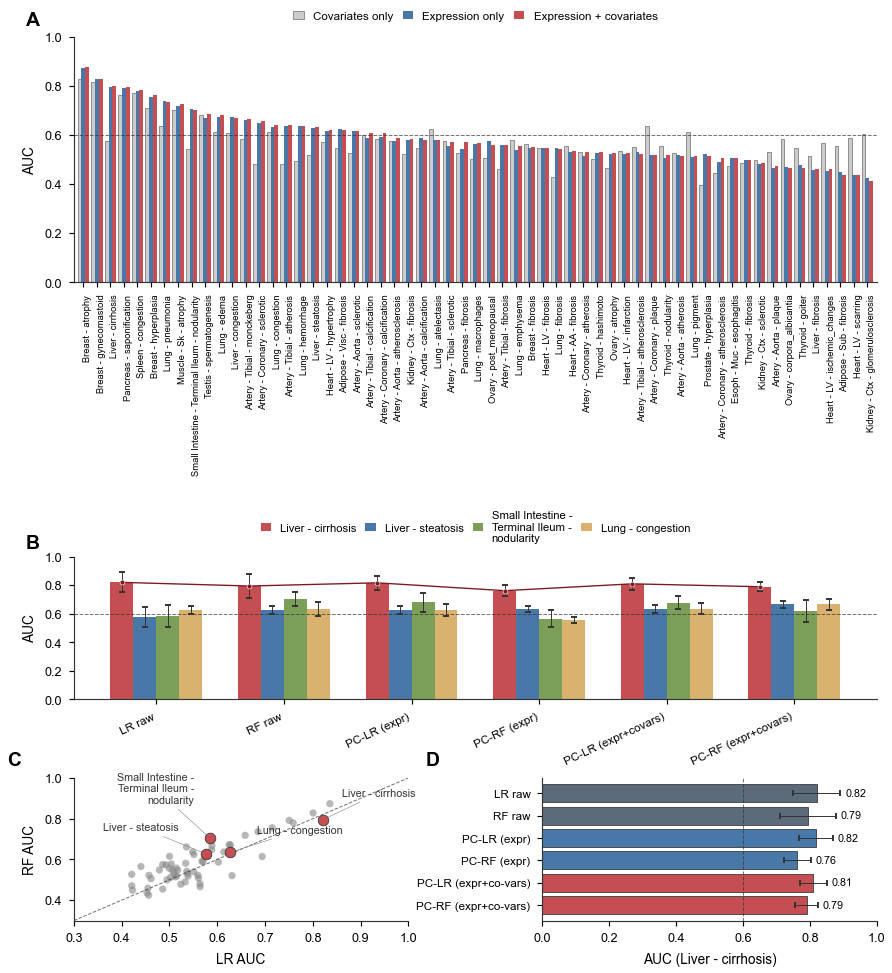

In [6]:
print("Building Figure S3 (three-way model comparison + LR vs RF + six-model)...")
from gtex_biomarkers.supp_figures import build_S3

fig = build_S3()
save_fig(fig, "S3")

## Figure S4 — PC importance back-projection validation


Building Figure S4 (PC importance back-projection validation)...
[load] loading cache ...


Loaded cache from /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/data/cache/processed_data.pkl
  X_wb: 803 samples × 59033 genes


[load] 803 samples x 20,000 genes

[compute] running per-fold PCA + AUC-selection for each qualifying pair

  pair: Liver | cirrhosis


    fold 1: PCA 347 comps, kept 337 PCs


    fold 2: PCA 347 comps, kept 340 PCs


...

    fold 4: PCA 505 comps, kept 473 PCs


    fold 5: PCA 505 comps, kept 476 PCs


    cross-fold Spearman rho (K=100): mean 0.955  min 0.936  max 0.968



[compute] panel E — rho(PC-derived, RF) at each K_pcs
  Liver | cirrhosis: {50: np.float64(0.5660402592503687), 100: np.float64(0.5627164706285794), 200: np.float64(0.5591577792256781)}
  Small Intestine - Terminal Ileum | nodularity: {50: np.float64(0.5522745627500663), 100: np.float64(0.5520211828096198), 200: np.float64(0.5526259655871817)}
  Liver | steatosis: {50: np.float64(0.2562112771357867), 100: np.float64(0.2458673550966728), 200: np.float64(0.23877480354648756)}
  Lung | congestion: {50: np.float64(0.24331011100938424), 100: np.float64(0.23449444953078505), 200: np.float64(0.2300948443579766)}

[compute] panel C — top-K Jaccard overlap (within shared gene universe)
  Liver | cirrhosis: common=241  Jaccard @[10, 25, 50, 100] = ['0.176', '0.250', '0.351', '0.493']
  Small Intestine - Terminal Ileum | nodularity: common=269  Jaccard @[10, 25, 50, 100] = ['0.111', '0.250', '0.351', '0.449']
  Liver | steatosis: common=283  Jaccard @[10, 25, 50, 100] = ['0.111', '0.087', '0.136

  wrote figure_S4.pdf


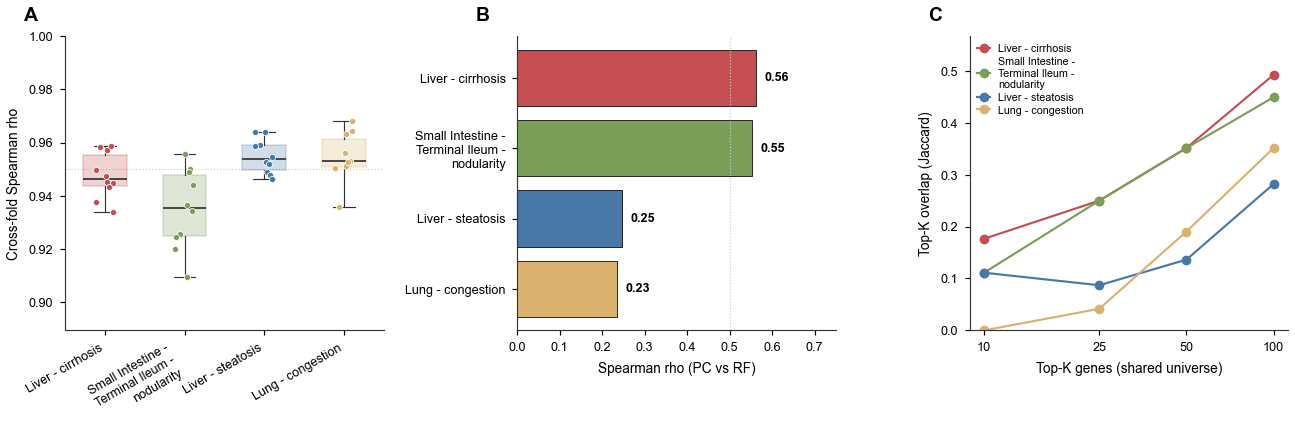

In [7]:
print("Building Figure S4 (PC importance back-projection validation)...")
from gtex_biomarkers.supp_figures import build_S4

fig = build_S4()
save_fig(fig, "S4")

## Figure S5 — Biological interpretation: signature specificity, plasma-organ enrichment, and Reactome pathway landscape


Building Figure S5 (signature specificity + plasma-organ + Reactome pathways)...


  wrote figure_S5.pdf


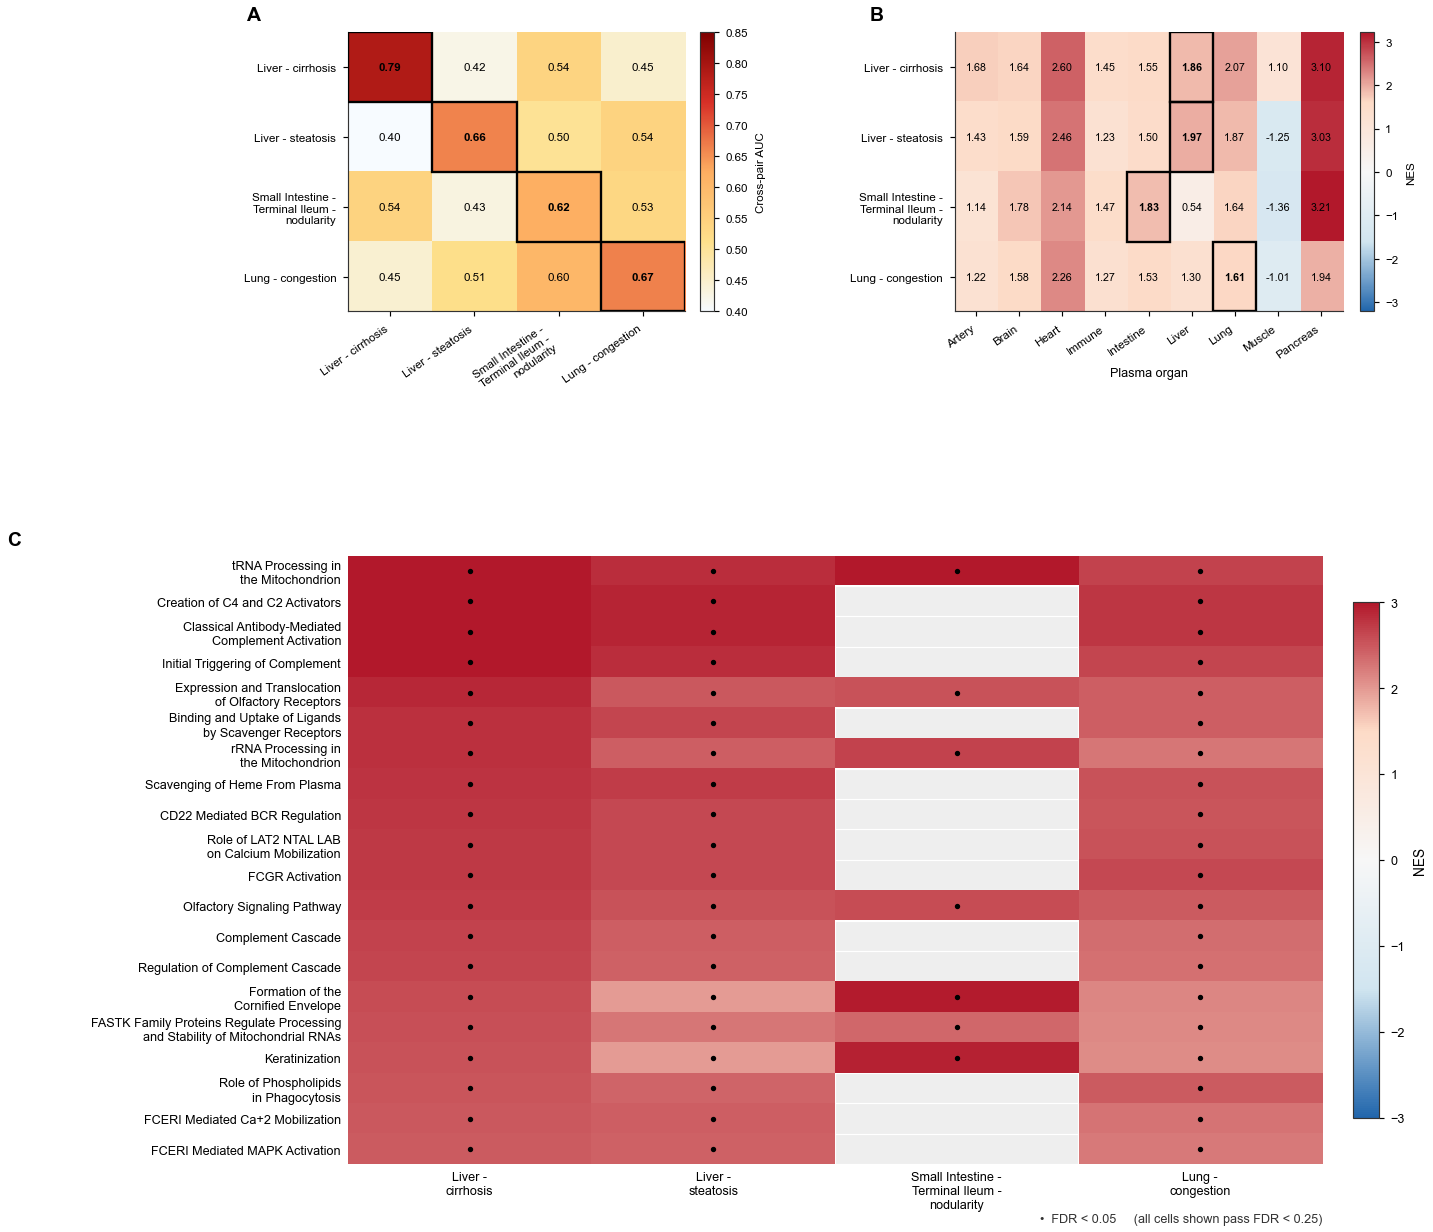

In [8]:
print("Building Figure S5 (signature specificity + plasma-organ + Reactome pathways)...")
from gtex_biomarkers.supp_figures import build_S5

fig = build_S5()
save_fig(fig, "S5")

## Figure S6 — Mendelian-randomization triage for Liver - steatosis


In [9]:
import importlib
from gtex_biomarkers.supp_figures import build_S6A, build_S6B, build_S6C

sys.path.insert(0, str(Config.ROOT_DIR / 'scripts' / 'figures'))
import compose_vector as _comp_s6
importlib.reload(_comp_s6)

print("Building Figure S6 (Liver - steatosis MR triage — 3-panel vector composite)...")

SUPP_PANELS = FIG_DIR / "panels_wip"
SUPP_PANELS.mkdir(parents=True, exist_ok=True)

_a = build_S6A(mr_steat_up, mr_steat_dn)
_b = build_S6B(mr_steat_up)
_c = build_S6C(mr_steat_dn)
for letter, f in [("A", _a), ("B", _b), ("C", _c)]:
    p = SUPP_PANELS / f"figS6{letter}.pdf"
    f.savefig(p, bbox_inches="tight")
    plt.close(f)
    print(f"  wrote {p.name}")

_comp_s6.compose_figure_S6(
    {L: SUPP_PANELS / f"figS6{L}.pdf" for L in "ABC"},
    FIG_DIR,
)

Building Figure S6 (Liver - steatosis MR triage — 3-panel vector composite)...
  wrote figS6A.pdf


  wrote figS6B.pdf
  wrote figS6C.pdf


wrote /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/output/figures/supp/figure_S6.pdf  page=960.0 x 918.8 pt  images=0


(PosixPath('/Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/output/figures/supp/figure_S6.pdf'),
 PosixPath('/Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/output/figures/supp/figure_S6.png'))